# Confronto Auto Elettriche vs Auto Ibride in Italia
### Autovetture per 1.000 autovetture circolanti — Dati ISTAT (comuni capoluogo di provincia)

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Caricamento e pulizia dati ──
# Il CSV ha intestazioni multi-livello; si salta la prima riga e si accede per posizione.
# col 3 = Territorio  |  col 6 = anno  |  col 7 = valore

def load_italia(path):
    df = pd.read_csv(path, encoding='utf-8-sig', header=None, skiprows=1)
    it = df[df[3] == 'Italia'][[6, 7]].copy()
    it.columns = ['Anno', 'Val']
    it['Anno'] = it['Anno'].astype(int)
    it['Val']  = pd.to_numeric(it['Val'], errors='coerce')
    return it.sort_values('Anno').reset_index(drop=True)

elettr = load_italia('../data/csv/auto_elettr_su_1000.csv')
ibride = load_italia('../data/csv/auto_ibride_su_1000.csv')

df = pd.merge(elettr, ibride, on='Anno', suffixes=('_Elettriche', '_Ibride'))
df[['Val_Elettriche', 'Val_Ibride']] = df[['Val_Elettriche', 'Val_Ibride']] / 10

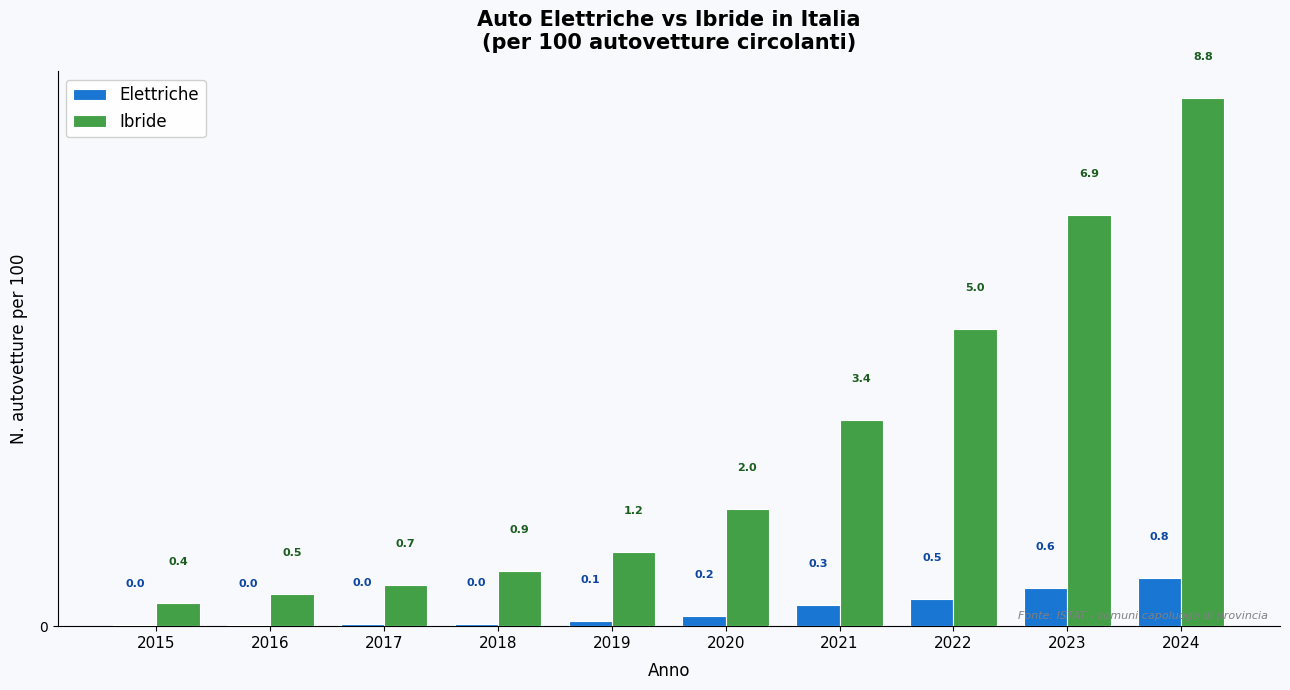

Grafico salvato come confronto_auto.png


In [42]:
# ── Grafico a istogrammi affiancati ──
anni  = df['Anno'].astype(str).tolist()
val_e = df['Val_Elettriche'].tolist()
val_i = df['Val_Ibride'].tolist()

x     = np.arange(len(anni))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#F7F9FC')
ax.set_facecolor('#F7F9FC')

bars_e = ax.bar(x - width/2, val_e, width, label='Elettriche',
                color='#1976D2', edgecolor='white', linewidth=0.8, zorder=3)
bars_i = ax.bar(x + width/2, val_i, width, label='Ibride',
                color='#43A047', edgecolor='white', linewidth=0.8, zorder=3)

# Etichette valori
for bar, v in zip(bars_e, val_e):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.6, f'{v:.1f}',
            ha='center', va='bottom', fontsize=8, color='#0D47A1', fontweight='bold')
for bar, v in zip(bars_i, val_i):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.6, f'{v:.1f}',
            ha='center', va='bottom', fontsize=8, color='#1B5E20', fontweight='bold')

# Assi e griglia
ax.set_xticks(x)
ax.set_xticklabels(anni, fontsize=11)
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.6, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Titoli
ax.set_title('Auto Elettriche vs Ibride in Italia\n(per 100 autovetture circolanti)',
             fontsize=15, fontweight='bold', pad=16)
ax.set_xlabel('Anno', fontsize=12, labelpad=8)
ax.set_ylabel('N. autovetture per 100', fontsize=12, labelpad=8)
ax.legend(fontsize=12, framealpha=0.9, loc='upper left')
ax.annotate('Fonte: ISTAT - comuni capoluogo di provincia',
            xy=(0.99, 0.01), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('confronto_auto.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico salvato come confronto_auto.png')